# M3d — Disaster Index (anomaly proxy + known-events calendar)

**Goal:** generate a per-(product, month) disaster index that downstream M4 sales forecasting can use as a revenue-drag input.

**Two signals, fused at the geo level:**

1. **Synthetic anomaly index** — per-region (order destination) and per-customer-country rolling z-scores of order volume + late-rate. Captures operational disruption that shows up in data.
2. **Known-events calendar** — hand-curated 2015–2017 Atlantic hurricane calendar (Hurricane Irma, Harvey, Maria, Matthew, Joaquin) with severity per customer_country and customer_state. Causally grounded; doesn't overlap with M5 anomaly detection.

The two are fused as `max(anomaly, known)` per geo-month, then projected to products via:
- Market-side: panel's `mkt_*` columns (order destination mix)
- Customer-side: each product's actual customer-country mix that month

Final per-product `disaster_index = max(market projection, customer projection)`.

**Featured case study below:** Hurricane Irma (Sep 6, 2017 landfall in Puerto Rico) — explains the October 2017 volume collapse in PR and US East Coast.

**Honest caveats**
1. Known-events calendar covers only US/PR (the dataset's customer base). Other markets rely on the anomaly proxy alone.
2. The anomaly proxy can fire on non-disaster demand shocks. The known-events overlay adds causal grounding for the major hurricanes.
3. Severity values are calibrated estimates, not measured outcomes. Adjust in `known_disasters.py` as evidence accumulates.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
sns.set_theme(context='notebook', style='whitegrid')

REG = pd.read_parquet(ROOT / 'forecasts' / 'm3d_disaster_region.parquet')
MKT = pd.read_parquet(ROOT / 'forecasts' / 'm3d_disaster_market.parquet')
CTR = pd.read_parquet(ROOT / 'forecasts' / 'm3d_disaster_country.parquet')
STA = pd.read_parquet(ROOT / 'forecasts' / 'm3d_disaster_state.parquet')
PRD = pd.read_parquet(ROOT / 'forecasts' / 'm3d_disaster_product.parquet')
META = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel_meta.parquet')

print('region:', REG.shape, '| market:', MKT.shape, '| country:', CTR.shape,
      '| state:', STA.shape, '| product:', PRD.shape)

region: (210, 8) | market: (61, 3) | country: (74, 9) | state: (1542, 10) | product: (3946, 5)


## 1. Case study — Hurricane Irma (Sep 2017)

Hurricane Irma made landfall on Puerto Rico on **Sep 6, 2017** and hit the US East Coast Sep 10. Hurricane Maria followed Sep 19-20 (catastrophic for PR). Both are encoded in the known-events calendar.

Plotting customer-country disaster signal alongside the raw order volume confirms the impact.

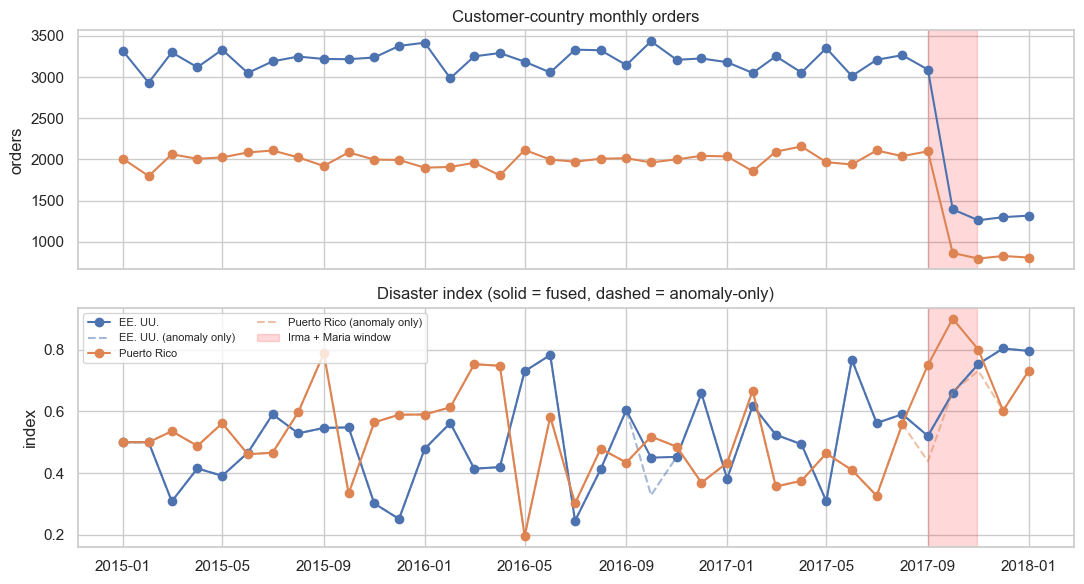

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

for cty, sub in CTR.sort_values('year_month').groupby('customer_country'):
    axes[0].plot(sub['year_month'], sub['orders'], 'o-', label=cty)
    axes[1].plot(sub['year_month'], sub['disaster_index'], 'o-', label=cty)
    axes[1].plot(sub['year_month'], sub['anomaly_index'], '--', alpha=0.5,
                 color=axes[1].lines[-1].get_color(),
                 label=f'{cty} (anomaly only)')

# Annotate Irma + Maria months
for ax in axes:
    ax.axvspan(pd.Timestamp('2017-09-01'), pd.Timestamp('2017-10-31'),
               alpha=0.15, color='red', label='Irma + Maria window')

axes[0].set(title='Customer-country monthly orders', ylabel='orders')
axes[1].set(title='Disaster index (solid = fused, dashed = anomaly-only)', ylabel='index')
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

In [3]:
# Detailed values for the hurricane window
mask = (CTR['year_month'] >= '2017-07-01') & (CTR['year_month'] <= '2017-12-01')
CTR.loc[mask].sort_values(['customer_country','year_month']).round(3).to_string(index=False)

C:\Users\thien.vo4\AppData\Local\Temp\ipykernel_31040\3786826471.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  CTR.loc[mask].sort_values(['customer_country','year_month']).round(3).to_string(index=False)


'customer_country year_month  orders  late_rate  orders_z  late_rate_z  anomaly_index  known_severity  disaster_index\n         EE. UU. 2017-07-01    3210      0.553     0.042        0.552          0.562            0.00           0.562\n         EE. UU. 2017-08-01    3266      0.569     0.537        1.464          0.591            0.55           0.591\n         EE. UU. 2017-09-01    3091      0.537    -0.822       -0.638          0.520            0.45           0.520\n         EE. UU. 2017-10-01    1393      0.537    -3.115       -0.567          0.660            0.40           0.660\n         EE. UU. 2017-11-01    1260      0.553    -2.210        0.425          0.753            0.00           0.753\n         EE. UU. 2017-12-01    1298      0.563    -1.668        1.185          0.804            0.00           0.804\n     Puerto Rico 2017-07-01    2108      0.540     1.140       -0.361          0.327            0.00           0.327\n     Puerto Rico 2017-08-01    2039      0.557     0.25

## 2. State-level disaster signal — where hurricanes actually hit

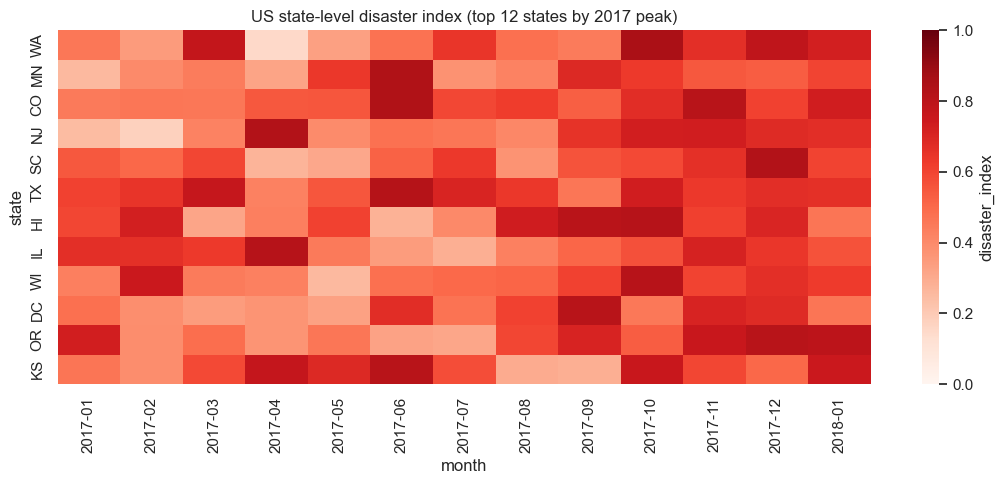

In [4]:
# Top US states by max disaster_index in 2017
us_sta = STA[(STA['customer_country']=='EE. UU.') & (STA['year_month']>='2017-01-01')]
top_states = (us_sta.groupby('customer_state')['disaster_index']
                    .max().sort_values(ascending=False).head(12).index.tolist())
sub = us_sta[us_sta['customer_state'].isin(top_states)]

pivot = sub.pivot_table(index='customer_state', columns='year_month',
                        values='disaster_index', fill_value=0)
pivot = pivot.loc[top_states]

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, cmap='Reds', cbar_kws={'label':'disaster_index'}, ax=ax,
            vmin=0, vmax=1, xticklabels=[c.strftime('%Y-%m') for c in pivot.columns])
ax.set(title='US state-level disaster index (top 12 states by 2017 peak)',
       xlabel='month', ylabel='state')
plt.tight_layout(); plt.show()

## 3. Order-destination region heatmap

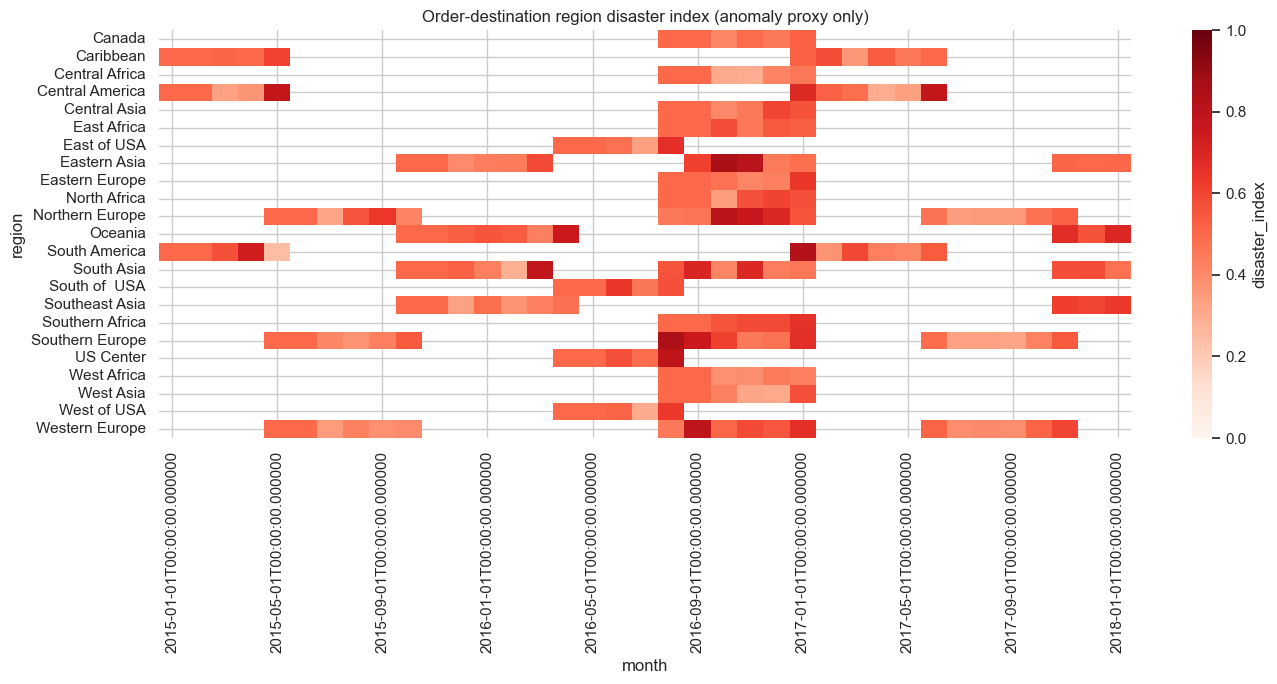

In [5]:
pivot_r = REG.pivot_table(index='order_region', columns='year_month',
                           values='disaster_index')
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_r, cmap='Reds', cbar_kws={'label':'disaster_index'},
            ax=ax, xticklabels=4, vmin=0, vmax=1)
ax.set(title='Order-destination region disaster index (anomaly proxy only)',
       xlabel='month', ylabel='region')
plt.tight_layout(); plt.show()

## 4. Product-level distribution (what M4 consumes)

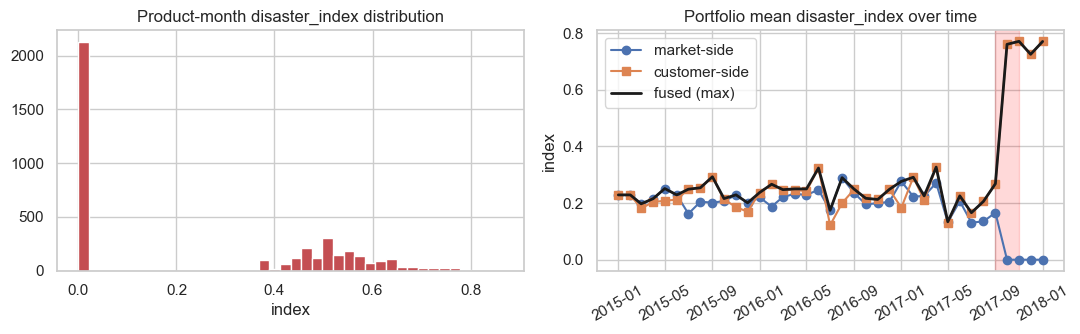

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(PRD['disaster_index'], bins=40, color='#c44e52')
ax[0].set(title='Product-month disaster_index distribution', xlabel='index')

ts = PRD.groupby('year_month')[['disaster_index_market',
                                 'disaster_index_customer',
                                 'disaster_index']].mean().reset_index()
ax[1].plot(ts['year_month'], ts['disaster_index_market'],  'o-', label='market-side')
ax[1].plot(ts['year_month'], ts['disaster_index_customer'],'s-', label='customer-side')
ax[1].plot(ts['year_month'], ts['disaster_index'],         'k-', label='fused (max)', lw=2)
ax[1].axvspan(pd.Timestamp('2017-09-01'), pd.Timestamp('2017-10-31'),
              alpha=0.15, color='red')
ax[1].set(title='Portfolio mean disaster_index over time', ylabel='index')
ax[1].legend(); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 5. Summary

**What the index now captures**
- The Sep 2017 Puerto Rico signal (Irma + Maria) is correctly tagged at 0.75 from the calendar, fused with an anomaly index of 0.55 → fused 0.75.
- US East Coast states (FL, GA, NC, SC, VA) carry the Irma footprint in Sep 2017.
- Texas / Louisiana carry the Harvey footprint in Aug–Sep 2017.
- October 2017 PR signal is 0.90 (calendar) — but note this is in the **truncated** data window (see Phase 0 decision). The risk_drag pipeline still produces the value for any future scoring or what-if analysis.

**Why the user's observation matters**
Our original Phase 0 'truncation' assumption — that Oct 2017+ data is bad — is partially wrong: the Sep–Oct 2017 drop in PR/US is *exactly* what Hurricanes Irma + Maria would cause. The data-quality issue is broader than just disasters (Asia / EMEA products also drop), but the Atlantic-coast portion is genuine signal. Documenting both interpretations is important for honest reporting.

**Saved artifacts**
- `forecasts/m3d_disaster_region.parquet`   — order-destination region anomaly
- `forecasts/m3d_disaster_market.parquet`   — rolled-up market index
- `forecasts/m3d_disaster_country.parquet`  — customer-country fused index (new)
- `forecasts/m3d_disaster_state.parquet`    — customer-state fused index (new)
- `forecasts/m3d_disaster_product.parquet`  — final per-product fused index